### Machine Learning Example - Regression Analysis with Wine Quality Data
In this lesson we will explore the Wine Quality data set which can be found on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php) and also on [Kaggle](https://www.kaggle.com/).

#### References
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php)
- [Kaggle](https://www.kaggle.com/)
- [EdX Courseware](https://courses.edx.org/courses/course-v1:ColumbiaX+BAMM.101x+3T2018/courseware/)

### Resources
- [Scikit Learn]()
- [sklearn cheat sheet](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Scikit_Learn_Cheat_Sheet_Python.pdf)
- [Pandas]()
- [Seaborn]()

We will begin by exploring the wine quality data set which may be imported from the UCI Machine Learning Repository.  Take a minute to look over the summary of the [wine quality data here](https://archive.ics.uci.edu/ml/datasets/Wine+Quality).

In [27]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
import pandas as pd

#read in the data using the pandas read_csv() function
df = pd.read_csv(url,header=0,sep=';')
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


Use the describe() function to generate a statistical summary of the variables and the info() function to get a count and data type for each of the variables.

In [28]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Evaluating Collinearity
As we have done previously, we will look at the correlations between each pair of variables both numerically and visually.

In [30]:
# matrix of numerical correlations
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


Plotting the correlation matrix with Seaborn.  [Source](https://seaborn.pydata.org/examples/many_pairwise_correlations.html)

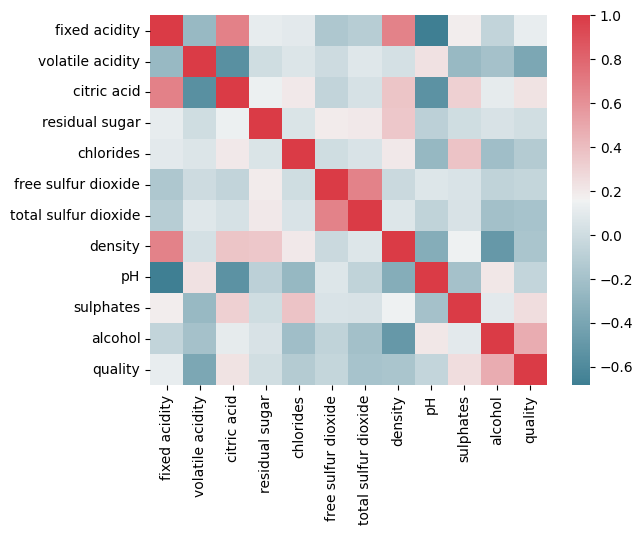

In [31]:
from string import ascii_letters
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr = df.corr()

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap=cmap)
plt.show()

Another heplful way to look at the distributions of the variables and the relationships between them is to examine a matrix of scatterplots which have the distributions of the individual variables along the diagonal.  We will use Seaborn for this.  

In [32]:
# import seaborn as sns
# sns.pairplot(df)

<Axes: xlabel='density', ylabel='alcohol'>

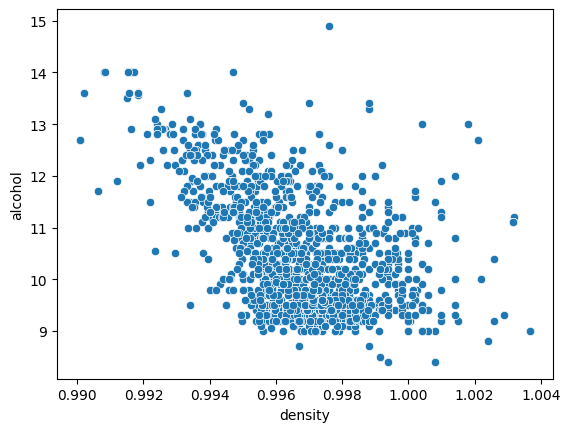

In [33]:
sns.scatterplot(x='density', y='alcohol', data=df)

<Axes: xlabel='density', ylabel='fixed acidity'>

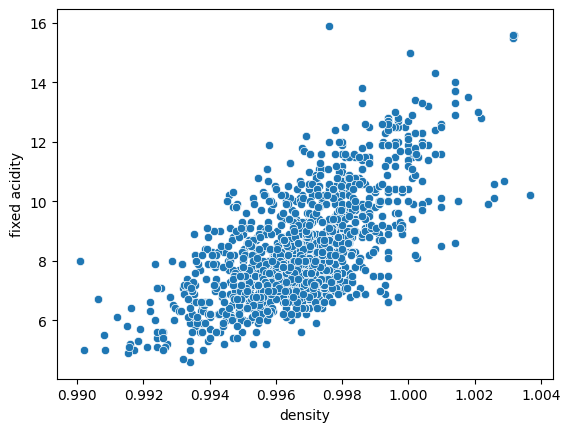

In [34]:
sns.scatterplot(x='density', y='fixed acidity', data=df)

Because the density variable appears to be correlated with other variables, it makes sense to remove it from the data frame.  We always want to avoid inputting similar information into the model to avoid exaggerating the predictive power of the model.  In statistical terms, this process is referred to as addressing multicollinearity.

In [35]:
X=df.drop(['density','quality'], axis=1)
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4


In [36]:
y=df['quality']
y.head()
y.unique()

array([5, 6, 7, 4, 8, 3])

Set up the training and testing data.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [38]:
lm = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=27)

In [39]:
lm.fit(X_train,y_train)

LinearRegression()

In [40]:
predictions = lm.predict(X_test)

Evaluate the model.

In [41]:
from sklearn import metrics
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MSE: 0.37367497636403446
RMSE: 0.6112896010599513


In [42]:
print('R sq: ',lm.score(X_train,y_train))
print('R sq: ',lm.score(X_test,y_test))

R sq:  0.3307665672102461
R sq:  0.4168763068307989


R-square a.k.a. Coefficient of Determination - "The percent of variation that is explained by the model"    

Train  
33% of the variation in wine quality is explained by the regression model

Test  
42% of the variation in wine quality is explained by the regression model  

In [43]:
reviews = []
for i in df['quality']:
    if i >= 1 and i <= 5:
        reviews.append('0')
    else:
        reviews.append('1')
df['reviews'] = reviews

In [44]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'reviews'],
      dtype='object')

In [45]:
df['reviews'].unique()

array(['0', '1'], dtype=object)

In [46]:
#count of each target variable
from collections import Counter
Counter(df['reviews'])

Counter({'0': 744, '1': 855})

In [47]:
X=df.drop(['density','quality','reviews'], axis=1)
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4


In [48]:
y = df['reviews']
y.head()

,reviews
0,0
1,0
2,0
3,1
4,0


### Scale the data using Standard Scaler
When variables are measured on different scales, it is common to standardize the values to even out the contributions that each variable makes to the model.  

In [49]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X

array([[-0.52835961,  0.96187667, -1.39147228, ...,  1.28864292,
        -0.57920652, -0.96024611],
       [-0.29854743,  1.96744245, -1.39147228, ..., -0.7199333 ,
         0.1289504 , -0.58477711],
       [-0.29854743,  1.29706527, -1.18607043, ..., -0.33117661,
        -0.04808883, -0.58477711],
       ...,
       [-1.1603431 , -0.09955388, -0.72391627, ...,  0.70550789,
         0.54204194,  0.54162988],
       [-1.39015528,  0.65462046, -0.77526673, ...,  1.6773996 ,
         0.30598963, -0.20930812],
       [-1.33270223, -1.21684919,  1.02199944, ...,  0.51112954,
         0.01092425,  0.54162988]])

## Try a Logistic regression approach

If we are not able to achieve good performance with one approach, we can try going back to the business question to see if there are adjustments we can make to help us develop a better model.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
lr = LogisticRegression(solver='lbfgs', multi_class='auto')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=27)

# Fit a logistic regression model
lr.fit(X_train, y_train)
lr_predict = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [26]:
#print confusion matrix and accuracy score
lr_conf_matrix = confusion_matrix(y_test, lr_predict)
lr_acc_score = accuracy_score(y_test, lr_predict)
print(lr_conf_matrix)
print(lr_acc_score*100)

[[165  43]
 [ 67 205]]
77.08333333333334


In [ ]:
#creating metric function
def metrics_score(actual, predicted):
    from sklearn.metrics import confusion_matrix, classification_report
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(6,3))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

              precision    recall  f1-score   support

           0       0.71      0.79      0.75       208
           1       0.83      0.75      0.79       272

    accuracy                           0.77       480
   macro avg       0.77      0.77      0.77       480
weighted avg       0.78      0.77      0.77       480



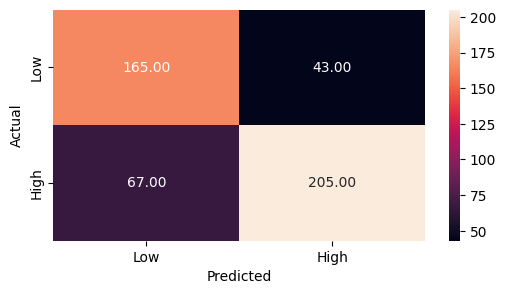

In [ ]:
metrics_score(y_test, lr_predict)